simulate 500 samples, 0.1 step, represents time from 0 to 5 seconds

simulated sampling frequency of 100 Hz

simulation of 2 signals: f1 = sin(x) and f2 = 0.5*sin(4*x)

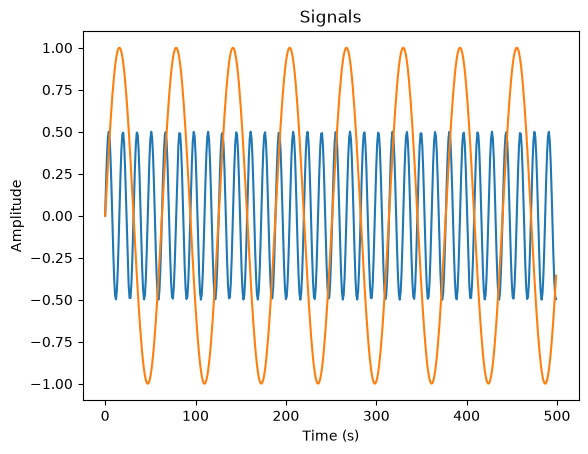

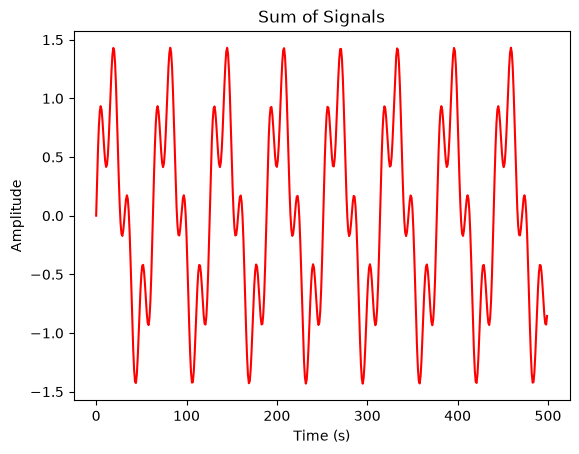

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# simulate 500 samples, 0.1 step, represents time from 0 to 5 seconds
# simulated sampling frequency of 100 Hz
# simulation of 2 signals: f1 = sin(x) and f2 = 0.5*sin(4*x)

x=np.arange(0,50,0.1)
f1=np.sin(x)
f2=0.5*np.sin(4*x)

plt.plot(f2)
plt.plot(f1)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Signals')
plt.show()
plt.plot(f1+f2,'r')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Sum of Signals')
plt.show()




Text(0.5, 0, 'Time (s)')

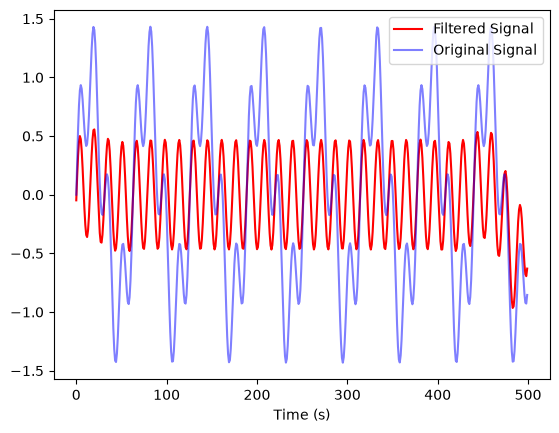

In [ ]:
# now I want to filter the signal f1+f2 to keep only the high 
# frequency component f2. 
# I will use a notch filter to remove the low frequency component f1.

from scipy.signal import iirnotch, filtfilt

f=f1+f2

# design a notch filter to remove the low frequency component f1 (1.59 Hz), 100 Hz sampling frequency, 1.59 Hz notch frequency, 1 quality factor
# 1 is the quality factor, which is the ratio of the notch frequency to the bandwidth of the notch filter. A higher quality factor means a narrower notch filter, which will remove more of the low frequency component f1.
b,a = iirnotch(1.59,1,100)  # notch filter at 1.59 Hz
f_filtered = filtfilt(b, a, f)  # apply the filter to the combined signal

plt.plot(f_filtered, color='red',label='Filtered Signal')
plt.plot(f, color='blue', alpha=0.5, label='Original Signal')
plt.legend()
plt.xlabel('Time (s)')


Apply the same filter to the EEG signal to remove 50 Hz noise.

In [ ]:
## apply the same filter to the EEG signal to remove 50 Hz noise. 
import pandas as pd
data=pd.read_csv('auditory_test.csv',delimiter='\t',header=None)
eeg=data[6]

# Apply the notch filter to the EEG signal
b,a = iirnotch(50,30,250)  # notch filter at 50 Hz
eeg_filtered = filtfilt(b, a, eeg)  # apply the filter to the EEG signal

plt.plot(eeg_filtered, color='red',label='Filtered Signal')
plt.plot(eeg, color='blue', alpha=0.5, label='Original Signal')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('EEG Signal with 50 Hz Noise Removed')
plt.show()

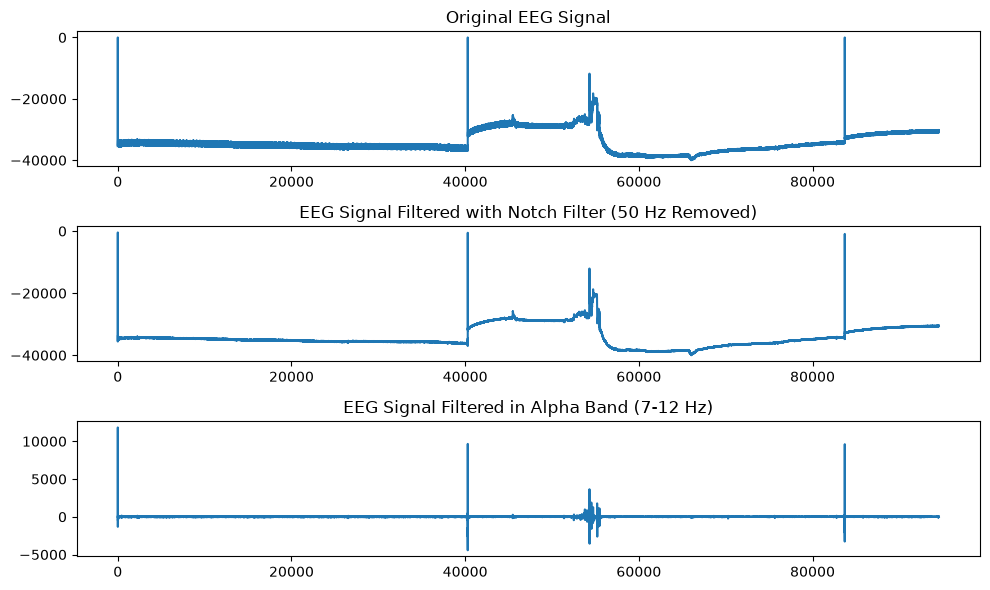

In [ ]:
# here we wil use a bandpass filter to keep only the  band (4-40 Hz) of the EEG signal.

from scipy.signal import butter, filtfilt

lowfreq = 4  # low frequency cutoff for bandpass filter
highfreq = 40  # high frequency cutoff for bandpass filter

nyquist_freq = 250 / 2  # Nyquist frequency is half the sampling frequency
b,a= butter(4, [lowfreq/nyquist_freq, highfreq/nyquist_freq], btype='band')  # bandpass filter for  band (4-40 Hz)

eeg_filtered_band=filtfilt(b, a, eeg_filtered)

fig,ax=plt.subplots(3,1,figsize=(10,6))

ax[0].plot(eeg)
ax[0].set_title('Original EEG Signal')
ax[1].plot(eeg_filtered)
ax[1].set_title('EEG Signal Filtered with Notch Filter (50 Hz Removed)')
ax[2].plot(eeg_filtered_band)
ax[2].set_title('EEG Signal Filtered in Alpha Band (7-12 Hz)')

plt.tight_layout()

Apply filter on the data from the file alpha_test.csv to keep only the alpha band (7-12 Hz) of the EEG signal.

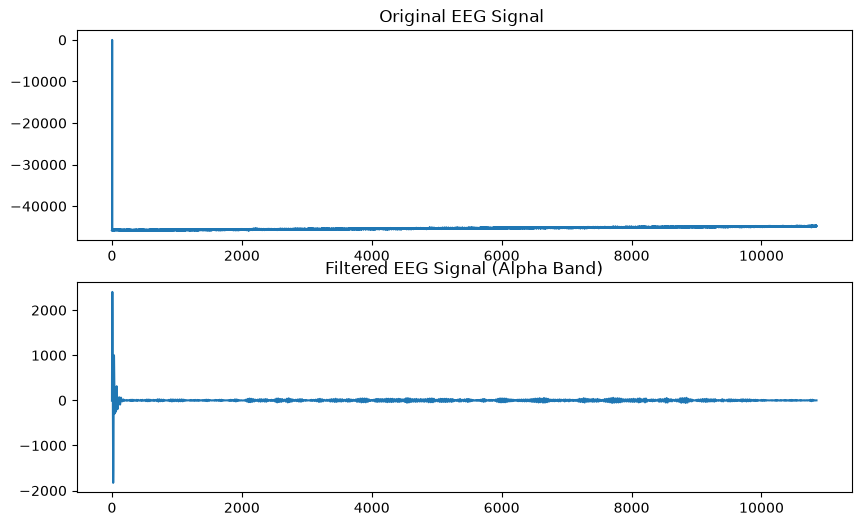

In [33]:
data_alpha=pd.read_csv('alpha_test.csv',delimiter='\t',header=None)
eeg_alpha=data_alpha[8]

nyquist_freq = 250 / 2  # Nyquist frequency is half the sampling frequency
b,a= butter(4, [7/nyquist_freq, 12/nyquist_freq], btype='band')  # bandpass filter for alpha band (7-12 Hz)
eeg_filtered_alpha=filtfilt(b, a, eeg_alpha)


fig,ax=plt.subplots(2,1,figsize=(10,6))
ax[0].plot(eeg_alpha)
ax[0].set_title('Original EEG Signal ')

ax[1].plot(eeg_filtered_alpha)
ax[1].set_title('Filtered EEG Signal (Alpha Band)')

plt.show()


(-200.0, 200.0)

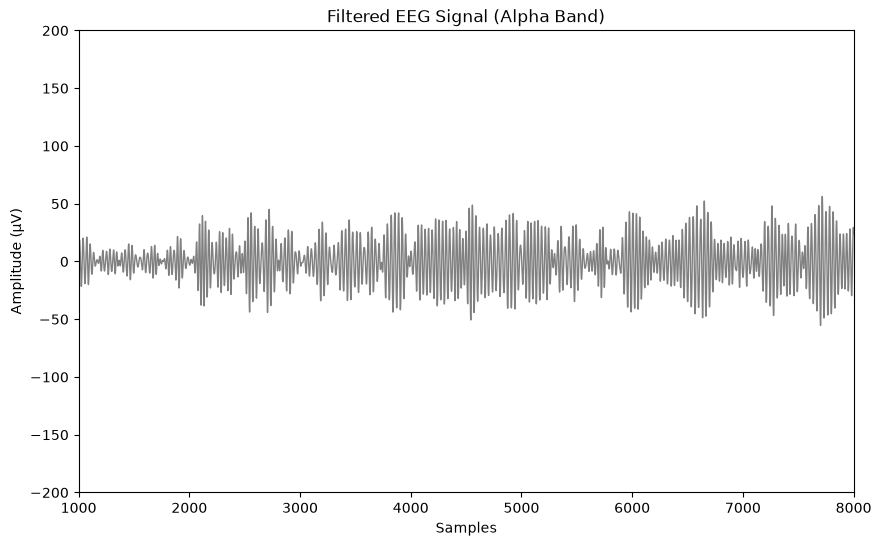

In [32]:

fig,axs= plt.subplots(1,1,figsize=(10,6))
axs.plot(eeg_filtered_alpha, color='gray', linewidth=1)
axs.set_title('Filtered EEG Signal (Alpha Band)')
axs.set_xlabel('Samples')
axs.set_ylabel('Amplitude (µV)')
axs.set_xlim(1000, 8000)
axs.set_ylim(-200, 200)